In [1]:
import pandas as pd
import numpy as np
%load_ext sql

#### Integrating the database

In [2]:
%sql sqlite:///chinook.db

 #### Checking table names

In [3]:
%%sql 
select name from sqlite_schema
where type = 'table' AND 
name NOT LIKE 'sqlite_%'



 * sqlite:///chinook.db
Done.


name
albums
artists
customers
employees
genres
invoices
invoice_items
media_types
playlists
playlist_track


### findings and insights 

In [4]:
%%sql 
select count(*)  as total_customers 
from Customers 

 * sqlite:///chinook.db
Done.


total_customers
59


In [5]:
%%sql 
-- calculating total sales 
select round(sum(total),2) as total_sales 
from invoices


 * sqlite:///chinook.db
Done.


total_sales
2328.6


In [6]:
%%sql 
-- find total no of artists
select count(*)   as total_artists
from artists

 * sqlite:///chinook.db
Done.


total_artists
275


In [7]:
%%sql 
-- find total tracks
select count(*) as total_tracks
from tracks

 * sqlite:///chinook.db
Done.


total_tracks
3503


In [8]:
%%sql 
-- determining total albums
select count(*) as total_albums
from albums

 * sqlite:///chinook.db
Done.


total_albums
347


In [9]:
%%sql 
--calculating total orders
select count(*) as total_orders
from invoices

 * sqlite:///chinook.db
Done.


total_orders
412


In [10]:
%%sql
select count(*) as total_employees
from employees

 * sqlite:///chinook.db
Done.


total_employees
8


In [11]:
%%sql 
-- find total genres
select count(*) as total_genres
from genres

 * sqlite:///chinook.db
Done.


total_genres
25


##### Q1 Identify the artists with highest sales and analyze their sales trend over time
 1a identifying the artists with the highest sales

In [12]:
%%sql q1a <<
select ar.name as artist_name, round(sum(ii.unitprice),2) as total_sales 
from invoice_items ii
left join tracks tr on ii.trackid = tr.trackid
left join albums al on tr.albumid = al.albumid
left join artists ar on al.artistid = ar.artistid
group by artist_name
order by total_sales DESC
limit 5


 * sqlite:///chinook.db
Done.
Returning data to local variable q1a


In [13]:
q1a

artist_name,total_sales
Iron Maiden,138.6
U2,105.93
Metallica,90.09
Led Zeppelin,86.13
Lost,81.59


In [14]:
# converting output to a dataframe
q1aDF = pd.DataFrame(q1a)
q1aDF

,artist_name,total_sales
0,Iron Maiden,138.60
1,U2,105.93
2,Metallica,90.09
3,Led Zeppelin,86.13
4,Lost,81.59


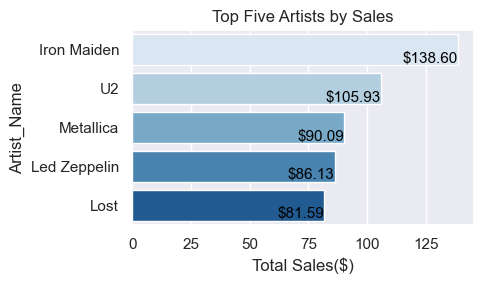

In [15]:
#plotting a bar chart showing the top five artists by sales
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

# importing warning to suppress future warnings message
import warnings
with warnings.catch_warnings():
    warnings.simplefilter(action='ignore', category=FutureWarning)
    
    sns.set(rc ={"figure.figsize":(5,3)})
    ax=sns.barplot(x= 'total_sales', y= 'artist_name' , data=q1aDF, palette="Blues")
    plt.subplots_adjust(left=0.15,right=0.85,top=0.85,bottom=0.25)
    ax.set_xlabel('Total Sales($)')
    ax.set_ylabel('Artist_Name')
    ax.set_title( "Top Five Artists by Sales")

    #add values on top of each bar 
    for bar in ax.patches:
        width = bar.get_width()
        height= bar.get_height()
        x=bar.get_x()+width
        y= bar.get_y()+height
        ax.text(x,y,f'${width:,.2f}', ha = 'right', va='bottom',color ='black', fontsize = 11)
                                                                                                                      
    plt.tight_layout()
    # save the plot as a file
    plt.savefig('seaborn_plot.png')

##### analyzing the sales trend over time on a yearly basis

In [16]:
%%sql q1b <<
with top_artists as(
 select 
    ar.artistid,
    ar.name as artist_name,
    round(sum(ii.unitprice),2) as total_sales
  from invoice_items ii
   left join tracks tr on ii.trackid = tr.trackid
   left join albums al on tr.albumid = al.albumid
   left join artists ar on al.artistid = ar.artistid
  group by artist_name
  order by total_sales DESC
  Limit 5
),
Yearly_sales as(
  Select
    tp.artistid,
    tp.artist_name,
    round(sum(ii.unitprice),2) as yearly_sales,
    strftime('%Y', i.invoiceDate) as sales_year
   from top_artists tp
    left join albums al on tp.artistid = al.artistid
    inner join tracks tr on al.albumid = tr.albumid
    inner join invoice_items ii on tr.trackid = ii.trackid
    left join invoices i on ii.invoiceid = i.invoiceid
   group by tp.artist_name, sales_year
   order by yearly_sales
)
select * from yearly_sales
order by sales_year, yearly_sales desc

 

 * sqlite:///chinook.db
Done.
Returning data to local variable q1b


In [17]:
q1b

artistid,artist_name,yearly_sales,sales_year
90,Iron Maiden,33.66,2009
22,Led Zeppelin,22.77,2009
50,Metallica,21.78,2009
90,Iron Maiden,34.65,2010
150,U2,26.73,2010
149,Lost,23.88,2010
50,Metallica,22.77,2010
22,Led Zeppelin,21.78,2010
150,U2,26.73,2011
149,Lost,21.89,2011


In [18]:
# converting the output to a dataframe
q1bDF = pd.DataFrame(q1b)
q1bDF

,artistid,artist_name,yearly_sales,sales_year
0,90,Iron Maiden,33.66,2009
1,22,Led Zeppelin,22.77,2009
2,50,Metallica,21.78,2009
3,90,Iron Maiden,34.65,2010
4,150,U2,26.73,2010
5,149,Lost,23.88,2010
6,50,Metallica,22.77,2010
7,22,Led Zeppelin,21.78,2010
8,150,U2,26.73,2011
9,149,Lost,21.89,2011


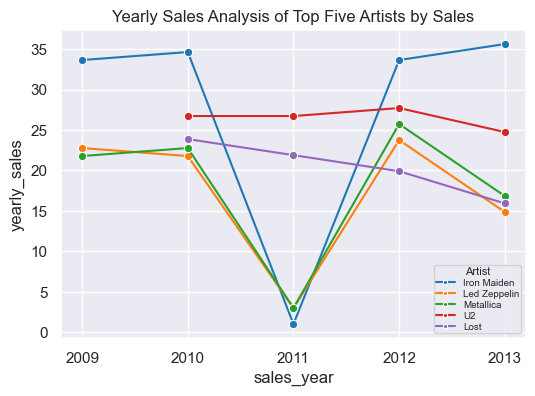

In [19]:
#plotting a line plot
# importing warning to suppress future warnings message
import warnings
with warnings.catch_warnings():
    warnings.simplefilter(action='ignore', category=FutureWarning)
    
    sns.set(rc ={"figure.figsize":(6,4)})
    plot = sns.lineplot(x = "sales_year", y= "yearly_sales", hue = "artist_name",  data = q1bDF, palette="tab10", linewidth=1.5, marker='o')
    plt.title("Yearly Sales Analysis of Top Five Artists by Sales")
    plt.legend(title ="Artist", fontsize =7, loc="lower right", title_fontsize=8, markerscale=0.5,labelspacing=0.2, borderpad=0.2)
    plt.grid(True)
    # save the visual
    plt.savefig('seaborn_linechart.png')

### Q2 Customer Purchase Patterns
#### segment customers based on purchase behaviour and identify key characteristics of high_value customers

In [20]:
%%sql q2a <<
-- calculating customer_totalpurchases
with customer_totalpurchase as (
    select c.customerid, c.firstname ||' '|| c.lastname as customer_name, round(sum(i.total),2) as totalpurchase,
            count(i.invoiceid) as purchasefrequency, max(i.invoicedate) as lastpurchase
     from customers c 
 left join invoices i on c.customerid = i.customerid
 group by c.customerid
),
-- sort customers by total purchase amount, assign row numbers
SortedCustomer_totalpurchase as (
     select *, Row_Number() over (order by totalpurchase desc) as row_num, count(*) over () as total_customers from customer_totalpurchase 
),
-- determine the top percentile cutoff
Top_percentile as (
     select min(totalpurchase) as cutoff 
     from(
         select totalpurchase from SortedCustomer_totalpurchase where row_num <= total_customers * 0.1)
)
-- filter customers based on the percentile to determine high value ones
select c.customerid, customer_name, ctp.totalpurchase
from customers c
left join customer_totalpurchase ctp on c.customerid = ctp.customerid
where ctp.totalpurchase >= (select cutoff from top_percentile)
group by c.customerid
order by totalpurchase desc

                                                                                  
     
    


 * sqlite:///chinook.db
Done.
Returning data to local variable q2a


In [21]:
q2a

CustomerId,customer_name,totalpurchase
6,Helena Holý,49.62
26,Richard Cunningham,47.62
57,Luis Rojas,46.62
46,Hugh O'Reilly,45.62
45,Ladislav Kovács,45.62


In [22]:
# converting output to a dataframe
q2aDF = pd.DataFrame(q2a)
q2aDF

,CustomerId,customer_name,totalpurchase
0,6,Helena Holý,49.62
1,26,Richard Cunningham,47.62
2,57,Luis Rojas,46.62
3,46,Hugh O'Reilly,45.62
4,45,Ladislav Kovács,45.62


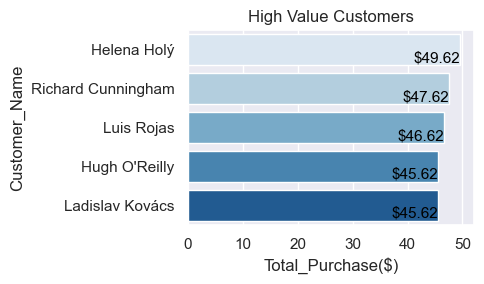

In [23]:
# plotting a barchart showing high value customers
# importing warning to suppress future warnings message
import warnings
with warnings.catch_warnings():
    warnings.simplefilter(action='ignore', category=FutureWarning)
    
    sns.set(rc ={"figure.figsize":(5,3)})
    ax=sns.barplot(x= 'totalpurchase', y= 'customer_name' , data=q2aDF, palette="Blues")
    plt.subplots_adjust(left=0.15,right=0.85,top=0.85,bottom =0.25)
    ax.set_xlabel('Total_Purchase($)')
    ax.set_ylabel('Customer_Name')
    ax.set_title( "High Value Customers")

    plt.tight_layout()

     #add values on top of each bar 
    for bar in ax.patches:
        width = bar.get_width()
        height= bar.get_height()
        x=bar.get_x()+width
        y= bar.get_y()+height
        ax.text(x,y,f'${width:,.2f}', ha = 'right', va='bottom',color ='black', fontsize = 11)
                                                              
    plt.savefig('seaborn_plot1.png')


#### Key characteristics of High value Customers 

In [24]:
%%sql q2b <<
-- calculate customer total purchase amount
with customer_totalpurchase as(
    select c.customerid, c.firstname ||' '|| c.lastname as customer_name, round(sum(i.total),2) as totalpurchase,
           count(i.invoiceid) as purchasefrequency, max(i.invoicedate) as lastpurchasedate
    from customers c
    left join invoices i on c.customerid = i.customerid
    group by c.customerid
),
-- identify high-value customers
TotalCustomer as (
    select count(*) as totalcustomers
    from customer_totalpurchase
),
top_percentile as (
    select cast(totalcustomers * 0.1 as integer) as top_customers
    from TotalCustomer
),
HighValue_Customers as (
    select * from customer_totalpurchase
    order by totalpurchase desc
    limit(select top_customers from top_percentile)
),
-- identify the most ordered genre amongst the high value customers
Genre_count as (
    select i.customerid, g.name as genre, count(*) as g_count
     from invoices i 
     left join invoice_items ii on i.invoiceid = ii.invoiceid
     left join tracks t on ii.trackid = t.trackid
     left join genres g on t.genreid = g.genreid
     where i.customerid in (select customerid from HighValue_Customers)
     group by i.customerid, g.name
),
Customer_highstordgenre as(
    select customerid, genre as top_ordedgenre
    from(
        select gc.customerid, gc.genre, gc.g_count, rank() over (PARTITION by gc.customerid 
    order by gc.g_count desc) as rank
    from genre_count gc)
where rank = 1
)
-- combine results and analyse key characteristics 
select customer_name, c.country, hvc.totalpurchase, hvc.purchasefrequency, hvc.lastpurchasedate, cg.top_ordedgenre
from customers c
inner join HighValue_Customers hvc on c.customerid =hvc.customerid
left join Customer_highstordgenre cg on c.customerid = cg.customerid
order by hvc.totalpurchase desc


 * sqlite:///chinook.db
Done.
Returning data to local variable q2b


In [25]:
q2b

customer_name,Country,totalpurchase,purchasefrequency,lastpurchasedate,top_ordedgenre
Helena Holý,Czech Republic,49.62,7,2013-11-13 00:00:00,Rock
Richard Cunningham,USA,47.62,7,2013-04-05 00:00:00,Rock
Luis Rojas,Chile,46.62,7,2012-10-14 00:00:00,Rock
Ladislav Kovács,Hungary,45.62,7,2013-07-20 00:00:00,Rock
Hugh O'Reilly,Ireland,45.62,7,2013-11-04 00:00:00,Rock


In [26]:
# convert output to dataframe
q2bDF = pd.DataFrame(q2b)
q2bDF

,customer_name,Country,totalpurchase,purchasefrequency,lastpurchasedate,top_ordedgenre
0,Helena Holý,Czech Republic,49.62,7,2013-11-13 00:00:00,Rock
1,Richard Cunningham,USA,47.62,7,2013-04-05 00:00:00,Rock
2,Luis Rojas,Chile,46.62,7,2012-10-14 00:00:00,Rock
3,Ladislav Kovács,Hungary,45.62,7,2013-07-20 00:00:00,Rock
4,Hugh O'Reilly,Ireland,45.62,7,2013-11-04 00:00:00,Rock


In [27]:
# converting lastpurchasedate in datetime format
import datetime
q2bDF['lastpurchasedate']= pd.to_datetime(q2bDF['lastpurchasedate'])

In [28]:
q2bDF

,customer_name,Country,totalpurchase,purchasefrequency,lastpurchasedate,top_ordedgenre
0,Helena Holý,Czech Republic,49.62,7,2013-11-13,Rock
1,Richard Cunningham,USA,47.62,7,2013-04-05,Rock
2,Luis Rojas,Chile,46.62,7,2012-10-14,Rock
3,Ladislav Kovács,Hungary,45.62,7,2013-07-20,Rock
4,Hugh O'Reilly,Ireland,45.62,7,2013-11-04,Rock


<Figure size 600x600 with 0 Axes>

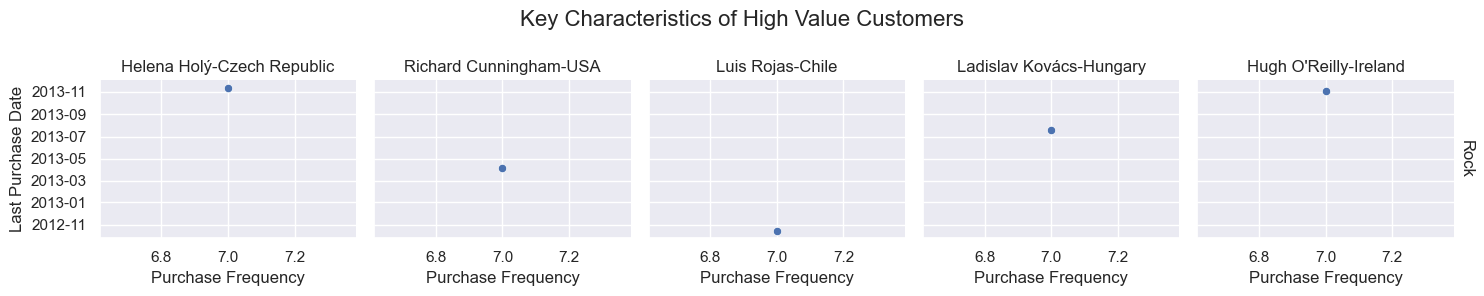

In [29]:
 # plotting a faceted grid to analyse customer characteristics
# combine customer_name and country into one into a single column
q2bDF['Customer_country'] = q2bDF ['customer_name'] + '-' + q2bDF['Country']

#create a faceted grid 
plt.figure(figsize= (6,6))
g =sns.FacetGrid(q2bDF,row='top_ordedgenre', col = 'Customer_country', margin_titles = True)

#map a plot to the facets 
g.map_dataframe(sns.scatterplot, y='lastpurchasedate', x='purchasefrequency')


#adjust the plot
g.set_axis_labels('Purchase Frequency', 'Last Purchase Date', fontsize= 12)
g.set_titles(col_template="{col_name}", row_template="{row_name}")

plt.suptitle('Key Characteristics of High Value Customers', fontsize= 16) 
plt.tight_layout()

plt.savefig('seaborn_facetgrid.png')


#### Question 3 Genre Popularity
Determine the most popular music genres and analyze the change in genre popularity over time periods

In [30]:
%%sql q3a <<
-- determing the popular genres 
select g.genreid, g.name as Genre_name, count(*) as Genre_count
from invoice_items il
left join invoices i on il.invoiceid = i.invoiceid
left join tracks t on il.trackid = t.trackid
left join genres g on t.genreid = g.genreid 
group by genre_name 
order by genre_count desc
limit 5

 * sqlite:///chinook.db
Done.
Returning data to local variable q3a


In [31]:
q3a

GenreId,Genre_name,Genre_count
1,Rock,835
7,Latin,386
3,Metal,264
4,Alternative & Punk,244
2,Jazz,80


In [32]:
# convert to dataframe
q3aDF = pd.DataFrame(q3a)
q3aDF

,GenreId,Genre_name,Genre_count
0,1,Rock,835
1,7,Latin,386
2,3,Metal,264
3,4,Alternative & Punk,244
4,2,Jazz,80


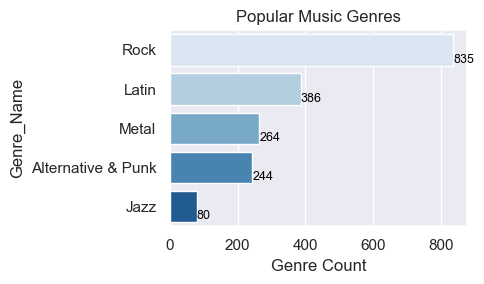

In [33]:
# plotting a barchart showing popular music genres 
# importing warning to suppress future warnings message
import warnings
with warnings.catch_warnings():
    warnings.simplefilter(action='ignore', category=FutureWarning)
    

    sns.set(rc = {'figure.figsize':(5,3)})
    ax = sns.barplot(x= 'Genre_count', y = 'Genre_name', data= q3aDF, palette = "Blues")
    plt.subplots_adjust(left=0.15,right=0.85,top=0.85,bottom =0.25)
    ax.set_xlabel('Genre Count')
    ax.set_ylabel('Genre_Name')
    ax.set_title('Popular Music Genres')

    plt.tight_layout()


    #add values on top of each bar 
    for bar in ax.patches:
        width = bar.get_width()
        height= bar.get_height()
        x=bar.get_x()+width
        y= bar.get_y()+height
        ax.text(x,y,f'{int(width)}', ha = 'left', va='bottom',color ='black', fontsize = 9)
        
    plt.tight_layout()
    plt.savefig('seaborn_plot2.png')


#### Analysis of changes in music genre over time

In [34]:
%%sql q3b <<
-- selecting top music genres
with top_musicgenre as( 
  select 
   g.genreid,
   g.name as genre_name,
   count(t.trackid) as track_count
from invoice_items il
  left join invoices i on il.invoiceid = i.invoiceid
  left join tracks t on il.trackid = t.trackid
  left join genres g on t.genreid = g.genreid
  group by t.genreid, genre_name
  order by track_count DESC
  limit 5
) 
-- yearly analysis of the top music genres  
select
  tg.genre_name,
  count(t.trackid) as track_count,
  strftime('%Y',i.invoiceDate) as year
from invoice_items il   
 left join invoices i on il.invoiceid = i.invoiceid
 left join tracks t on il.trackid = t.trackid
 inner join top_musicgenre tg on t.genreid = tg.genreid
group by year, genre_name
order by year, track_count desc


 * sqlite:///chinook.db
Done.
Returning data to local variable q3b


In [35]:
q3b

genre_name,track_count,year
Rock,180,2009
Latin,83,2009
Alternative & Punk,63,2009
Metal,62,2009
Jazz,20,2009
Rock,157,2010
Latin,78,2010
Metal,54,2010
Alternative & Punk,40,2010
Jazz,16,2010


In [36]:
#convert output to dataframe
q3bDF = pd.DataFrame(q3b)
q3bDF

,genre_name,track_count,year
0,Rock,180,2009
1,Latin,83,2009
2,Alternative & Punk,63,2009
3,Metal,62,2009
4,Jazz,20,2009
5,Rock,157,2010
6,Latin,78,2010
7,Metal,54,2010
8,Alternative & Punk,40,2010
9,Jazz,16,2010


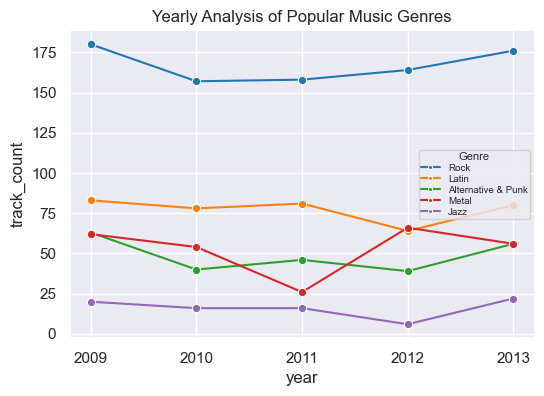

In [37]:
#plotting a line plot
# importing warning to suppress future warnings message
import warnings
with warnings.catch_warnings():
    warnings.simplefilter(action='ignore', category=FutureWarning)
    
    sns.set(rc ={"figure.figsize":(6,4)})
    plot = sns.lineplot(x = "year", y= "track_count", hue = "genre_name",  data = q3bDF, palette="tab10", linewidth=1.5, marker= 'o')
    plt.title("Yearly Analysis of Popular Music Genres")
    plt.legend(title ="Genre", fontsize =7, loc="right", title_fontsize=8, markerscale=0.5,labelspacing=0.2, borderpad=0.2)
    plt.grid(True)
    # save the visual
    plt.savefig('seaborn_linechart2.png')

#### Question 4 Sales over Time
Analyse Monthly and yearly sales trends including seasonal effects and significant sales events

In [38]:
%%sql q4a <<
-- monthly sales trend over time 
select 
strftime('%Y-%m', invoicedate) as Month_year, 
round(sum(total),2) as total_sales 
from invoices i 
group by month_year 
order by month_year


 * sqlite:///chinook.db
Done.
Returning data to local variable q4a


In [39]:
q4a

Month_year,total_sales
2009-01,35.64
2009-02,37.62
2009-03,37.62
2009-04,37.62
2009-05,37.62
2009-06,37.62
2009-07,37.62
2009-08,37.62
2009-09,37.62
2009-10,37.62


In [40]:
# convert output to dataframe
q4aDF = pd.DataFrame(q4a)
q4a

Month_year,total_sales
2009-01,35.64
2009-02,37.62
2009-03,37.62
2009-04,37.62
2009-05,37.62
2009-06,37.62
2009-07,37.62
2009-08,37.62
2009-09,37.62
2009-10,37.62


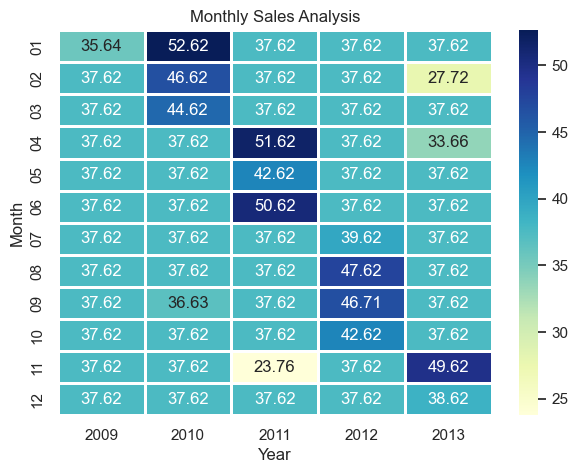

In [41]:
# split month_year into month and year columns 
q4aDF[['Year', 'Month']] = q4aDF['Month_year'].str.split('-', expand=True)

# convert the year column to integers 
q4aDF['Year'] = q4aDF['Year'].astype(int)

#convert month column to a categorical type for correct ordering
months_order=["01","02", "03", "04", "05", "06", "07", "08", "09", "10", "11", "12"]
q4aDF['Month']= pd.Categorical(q4aDF['Month'], categories = months_order, ordered = True)


#pivot the data to create a matrix for the heatmap
heatmap_data = q4aDF.pivot(index= 'Month', columns="Year", values="total_sales") 

#create a heatmap
plt.figure(figsize=(7,5))
sns.heatmap(heatmap_data, cmap = "YlGnBu", annot = True , fmt =".2f", linewidths = 1)
plt.title("Monthly Sales Analysis")
plt.xlabel("Year")
plt.ylabel("Month")
plt.savefig('seaborn_heatmap.png')





In [42]:
%%sql q4b <<
-- yearly sales trend over time
select 
strftime('%Y', invoicedate) as year, 
round(sum(total),2) as total_sales 
from invoices i 
group by year 
order by year

 * sqlite:///chinook.db
Done.
Returning data to local variable q4b


In [43]:
q4b

year,total_sales
2009,449.46
2010,481.45
2011,469.58
2012,477.53
2013,450.58


In [44]:
#convert output to dataframe 
q4bDF = pd.DataFrame(q4b)
q4bDF


,year,total_sales
0,2009,449.46
1,2010,481.45
2,2011,469.58
3,2012,477.53
4,2013,450.58


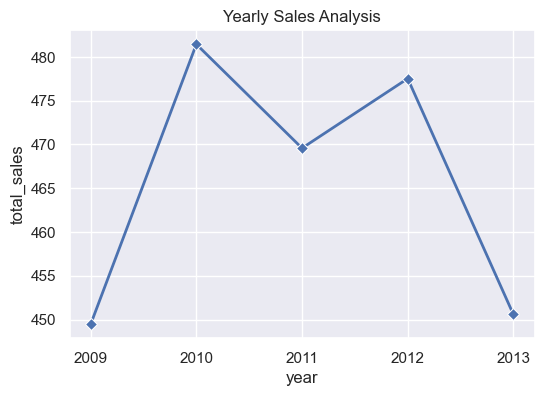

In [45]:
#plotting a line chart to show yearly sales
# importing warning to suppress future warnings message
import warnings
with warnings.catch_warnings():
    warnings.simplefilter(action='ignore', category=FutureWarning)
    
    sns.set(rc ={"figure.figsize":(6,4)})
    plot = sns.lineplot(x = "year", y= "total_sales",   data = q4bDF, linewidth=2, marker= 'D')
    plt.title("Yearly Sales Analysis")
    plt.grid(True)
    # save the visual
    plt.savefig('seaborn plot3')

### Question 5 Customer Lifetime Value
calculate the lifetime value of customers based on their purchase history and provide recommendations for improving customer retention

In [48]:
%%sql q5 <<
--getting customer purchase information
with customer_purchaseinfo as( 
  select c.customerid, firstname ||' '|| lastname as customer_name, round(sum(ii.unitprice),2) as amount, count(DISTINCT i.invoiceid) as no_of_invoices,  
 min(i.invoicedate) as firstprchasedate, max(i.invoicedate) as lastpurchasedate
 from customers c 
 left join invoices i on c.customerid = i.customerid
 left join invoice_items ii on i.invoiceid = ii.invoiceid
 group by c.customerid
),
--determining customer life time
customer_lifetime as( 
  select customerid, customer_name, no_of_invoices, amount, round((julianday(lastpurchasedate)-julianday(firstprchasedate))/365.0,2) as customer_lifetime
  from customer_purchaseinfo
 )
 select customerid,customer_name,(customer_lifetime), round(amount/no_of_invoices,2) as avg_purchasevalue, 
 round(no_of_invoices/customer_lifetime,2) as purchase_frequency, round((amount/no_of_invoices)*(no_of_invoices/customer_lifetime)*customer_lifetime,2) as CLTV
 from customer_lifetime
 order by CLTV desc

 * sqlite:///chinook.db
Done.
Returning data to local variable q5


In [49]:
q5

customerid,customer_name,customer_lifetime,avg_purchasevalue,purchase_frequency,CLTV
6,Helena Holý,4.35,7.09,1.61,49.62
26,Richard Cunningham,3.41,6.8,2.05,47.62
57,Luis Rojas,3.53,6.66,1.98,46.62
45,Ladislav Kovács,3.53,6.52,1.98,45.62
46,Hugh O'Reilly,4.75,6.52,1.47,45.62
24,Frank Ralston,3.53,6.23,1.98,43.62
28,Julia Barnett,3.53,6.23,1.98,43.62
37,Fynn Zimmermann,4.37,6.23,1.6,43.62
7,Astrid Gruber,3.53,6.09,1.98,42.62
25,Victor Stevens,4.75,6.09,1.47,42.62


In [50]:
# convert output to a dataframe 
Q5DF = pd.DataFrame(q5)
Q5DF

,customerid,customer_name,customer_lifetime,avg_purchasevalue,purchase_frequency,CLTV
0,6,Helena Holý,4.35,7.09,1.61,49.62
1,26,Richard Cunningham,3.41,6.80,2.05,47.62
2,57,Luis Rojas,3.53,6.66,1.98,46.62
3,45,Ladislav Kovács,3.53,6.52,1.98,45.62
4,46,Hugh O'Reilly,4.75,6.52,1.47,45.62
5,24,Frank Ralston,3.53,6.23,1.98,43.62
6,28,Julia Barnett,3.53,6.23,1.98,43.62
7,37,Fynn Zimmermann,4.37,6.23,1.60,43.62
8,7,Astrid Gruber,3.53,6.09,1.98,42.62
9,25,Victor Stevens,4.75,6.09,1.47,42.62


In [51]:
#count the number of customers for each CLTV value and group customer according to their value 
cltv_counts= Q5DF['CLTV'].value_counts().sort_index().reset_index()
cltv_counts.columns = ['CLTV', 'Number of Customers']
cltv_counts.head()

,CLTV,Number of Customers
0,36.64,1
1,37.62,30
2,38.62,6
3,39.62,8
4,40.62,3


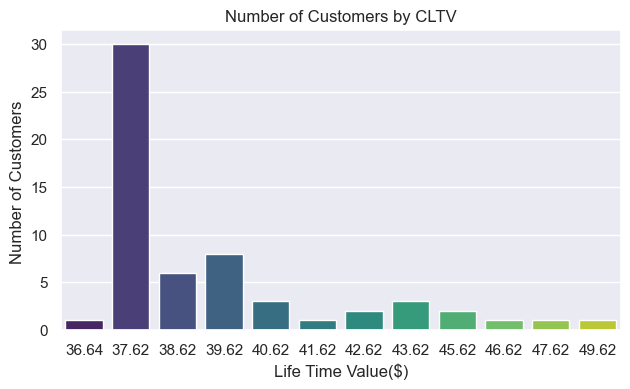

In [52]:
## importing warning to suppress future warnings message
import warnings
with warnings.catch_warnings():
    warnings.simplefilter(action='ignore', category=FutureWarning)

    #create a bar plot with seaborn showing customers in different lifetime value clusters 
    sns.set(rc ={"figure.figsize":(8,5)})
    ax= sns.barplot(y= 'Number of Customers', x= 'CLTV', data= cltv_counts, palette = 'viridis')
    plt.subplots_adjust(left=0.15,right=0.85,top=0.85,bottom=0.25)
  
    plt.xlabel('Life Time Value($)')
    plt.ylabel('Number of Customers ')
    plt.title('Number of Customers by CLTV') 
    plt.savefig('seaborn_plot4.png')



### Question 6: Market Basket Analysis
Perform association rule mining to find common combination of tracks or albums purchased together

In [53]:
%%sql q6 <<
--  querying to merge, tracks, albums and purchases
select invoiceid, t.trackid, a.albumid, t.name as track_name, a.Title
from invoice_items ii 
left join tracks t on ii.trackid =t.trackid
left join albums a on t.albumid = a.albumid

 * sqlite:///chinook.db
Done.
Returning data to local variable q6


In [54]:
q6

InvoiceId,TrackId,AlbumId,track_name,Title
1,2,2,Balls to the Wall,Balls to the Wall
1,4,3,Restless and Wild,Restless and Wild
2,6,1,Put The Finger On You,For Those About To Rock We Salute You
2,8,1,Inject The Venom,For Those About To Rock We Salute You
2,10,1,Evil Walks,For Those About To Rock We Salute You
2,12,1,Breaking The Rules,For Those About To Rock We Salute You
3,16,4,Dog Eat Dog,Let There Be Rock
3,20,4,Overdose,Let There Be Rock
3,24,5,Love In An Elevator,Big Ones
3,28,5,Janie's Got A Gun,Big Ones


In [55]:
#convert the output to a dataframe
q6DF= pd.DataFrame(q6)
q6DF

,InvoiceId,TrackId,AlbumId,track_name,Title
0,1,2,2,Balls to the Wall,Balls to the Wall
1,1,4,3,Restless and Wild,Restless and Wild
2,2,6,1,Put The Finger On You,For Those About To Rock We Salute You
3,2,8,1,Inject The Venom,For Those About To Rock We Salute You
4,2,10,1,Evil Walks,For Those About To Rock We Salute You
...,...,...,...,...,...
2235,411,3136,141,Looking For Love,Greatest Hits
2236,411,3145,141,Sweet Lady Luck,Greatest Hits
2237,411,3154,248,Feirinha da Pavuna/Luz do Repente/Bagaço da La...,Ao Vivo [IMPORT]
2238,411,3163,248,Samba pras moças,Ao Vivo [IMPORT]


In [56]:
q6DF.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   InvoiceId   2240 non-null   int64 
 1   TrackId     2240 non-null   int64 
 2   AlbumId     2240 non-null   int64 
 3   track_name  2240 non-null   object
 4   Title       2240 non-null   object
dtypes: int64(3), object(2)
memory usage: 87.6+ KB


In [57]:
import warnings
with warnings.catch_warnings():
    warnings.simplefilter(action='ignore', category=FutureWarning)

    #create a basket matrix where each row is an Invoiceid and each column is an album_name
    basket = pd.crosstab(q6DF['InvoiceId'],q6DF[ 'Title'])
    
    #convert all values greater than 1 to 1
    basket = basket.applymap(lambda x:1 if x>0 else 0)
basket

Title,...And Justice For All,20th Century Masters - The Millennium Collection: The Best of Scorpions,A Matter of Life and Death,A Real Dead One,A Real Live One,A TempestadeTempestade Ou O Livro Dos Dias,A-Sides,Ace Of Spades,Achtung Baby,Acústico,...,Voodoo Lounge,Vozes do MPB,Vs.,Wagner: Favourite Overtures,Walking Into Clarksdale,War,Warner 25 Anos,Weill: The Seven Deadly Sins,Zooropa,[1997] Black Light Syndrome
InvoiceId,,,,,,,,,,,,,,,,,,,,,
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
5,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
408,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
409,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
410,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,1,0


In [58]:
# apply hot encoding
def hot_encode(x): 
    if(x<= 0): 
        return 0
    if(x>= 1): 
        return 1
  
# Encoding the datasets 
basket_encoded = basket.applymap(hot_encode) 
basket = basket_encoded 

C:\Users\bartholomew\AppData\Local\Temp\ipykernel_6288\4235690366.py:9: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  basket_encoded = basket.applymap(hot_encode)


In [59]:
#filter for only invoices with 2 or more items
basket_filtered = basket_encoded[(basket_encoded > 0).sum(axis=1) >= 2]

basket_filtered

Title,...And Justice For All,20th Century Masters - The Millennium Collection: The Best of Scorpions,A Matter of Life and Death,A Real Dead One,A Real Live One,A TempestadeTempestade Ou O Livro Dos Dias,A-Sides,Ace Of Spades,Achtung Baby,Acústico,...,Voodoo Lounge,Vozes do MPB,Vs.,Wagner: Favourite Overtures,Walking Into Clarksdale,War,Warner 25 Anos,Weill: The Seven Deadly Sins,Zooropa,[1997] Black Light Syndrome
InvoiceId,,,,,,,,,,,,,,,,,,,,,
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
5,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
11,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
403,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
404,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
409,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [60]:
from mlxtend.frequent_patterns import apriori, association_rules
#Generate the frequent itemsets
frequent_itemsets = apriori(basket_filtered, min_support=0.018, use_colnames=True, verbose= 1).sort_values("support",ascending=False)
frequent_itemsets

Processing 474 combinations | Sampling itemset size 653


C:\Users\bartholomew\anaconda\Lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:109: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


,support,itemsets
74,0.074074,(Greatest Hits)
190,0.041667,(Unplugged)
120,0.032407,(Minha Historia)
9,0.027778,(Acústico MTV)
15,0.027778,(Angel Dust)
...,...,...
211,0.018519,"(A-Sides, Rotten Apples: Greatest Hits)"
210,0.018519,"(A TempestadeTempestade Ou O Livro Dos Dias, M..."
209,0.018519,"(A Real Live One, A Real Dead One)"
205,0.018519,(War)


In [61]:


# Collecting the inferred rules in a dataframe 
rules = association_rules(frequent_itemsets, metric ="confidence", min_threshold =1) 
rules


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,leverage,conviction,zhangs_metric
0,"(BackBeat Soundtrack, The Best Of Billy Cobham)",(Out Of Exile),0.018519,0.018519,0.018519,1.0,54.0,0.018176,inf,1.0
1,"(BackBeat Soundtrack, Out Of Exile)",(The Best Of Billy Cobham),0.018519,0.018519,0.018519,1.0,54.0,0.018176,inf,1.0
2,"(The Best Of Billy Cobham, Out Of Exile)",(BackBeat Soundtrack),0.018519,0.018519,0.018519,1.0,54.0,0.018176,inf,1.0
3,(BackBeat Soundtrack),"(The Best Of Billy Cobham, Out Of Exile)",0.018519,0.018519,0.018519,1.0,54.0,0.018176,inf,1.0
4,(The Best Of Billy Cobham),"(BackBeat Soundtrack, Out Of Exile)",0.018519,0.018519,0.018519,1.0,54.0,0.018176,inf,1.0
...,...,...,...,...,...,...,...,...,...,...
1891,(Outbreak),"(Purpendicular, Slaves And Masters, The Battle...",0.018519,0.018519,0.018519,1.0,54.0,0.018176,inf,1.0
1892,(Slaves And Masters),"(Purpendicular, Outbreak, The Battle Rages On,...",0.018519,0.018519,0.018519,1.0,54.0,0.018176,inf,1.0
1893,(The Battle Rages On),"(Purpendicular, Outbreak, Slaves And Masters, ...",0.018519,0.018519,0.018519,1.0,54.0,0.018176,inf,1.0
1894,(Stormbringer),"(Purpendicular, Outbreak, Slaves And Masters, ...",0.018519,0.018519,0.018519,1.0,54.0,0.018176,inf,1.0


In [44]:
filtered_rules=rules[(rules['confidence']>=0.5)&(rules['lift']>=1.2)]
rules

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,leverage,conviction,zhangs_metric
0,"(BackBeat Soundtrack, The Best Of Billy Cobham)",(Out Of Exile),0.018519,0.018519,0.018519,1.0,54.0,0.018176,inf,1.0
1,"(BackBeat Soundtrack, Out Of Exile)",(The Best Of Billy Cobham),0.018519,0.018519,0.018519,1.0,54.0,0.018176,inf,1.0
2,"(The Best Of Billy Cobham, Out Of Exile)",(BackBeat Soundtrack),0.018519,0.018519,0.018519,1.0,54.0,0.018176,inf,1.0
3,(BackBeat Soundtrack),"(The Best Of Billy Cobham, Out Of Exile)",0.018519,0.018519,0.018519,1.0,54.0,0.018176,inf,1.0
4,(The Best Of Billy Cobham),"(BackBeat Soundtrack, Out Of Exile)",0.018519,0.018519,0.018519,1.0,54.0,0.018176,inf,1.0
...,...,...,...,...,...,...,...,...,...,...
1891,(Vault: Def Leppard's Greatest Hits),"(Outbreak, The Battle Rages On, Stormbringer, ...",0.018519,0.018519,0.018519,1.0,54.0,0.018176,inf,1.0
1892,(Outbreak),"(Vault: Def Leppard's Greatest Hits, Stormbrin...",0.018519,0.018519,0.018519,1.0,54.0,0.018176,inf,1.0
1893,(Stormbringer),"(Vault: Def Leppard's Greatest Hits, Outbreak,...",0.018519,0.018519,0.018519,1.0,54.0,0.018176,inf,1.0
1894,(The Battle Rages On),"(Vault: Def Leppard's Greatest Hits, Outbreak,...",0.018519,0.018519,0.018519,1.0,54.0,0.018176,inf,1.0


In [62]:
sorted_rules = rules.sort_values(by=['confidence', 'lift'], ascending = False)
sorted_rules

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,leverage,conviction,zhangs_metric
0,"(BackBeat Soundtrack, The Best Of Billy Cobham)",(Out Of Exile),0.018519,0.018519,0.018519,1.0,54.0,0.018176,inf,1.000000
1,"(BackBeat Soundtrack, Out Of Exile)",(The Best Of Billy Cobham),0.018519,0.018519,0.018519,1.0,54.0,0.018176,inf,1.000000
2,"(The Best Of Billy Cobham, Out Of Exile)",(BackBeat Soundtrack),0.018519,0.018519,0.018519,1.0,54.0,0.018176,inf,1.000000
3,(BackBeat Soundtrack),"(The Best Of Billy Cobham, Out Of Exile)",0.018519,0.018519,0.018519,1.0,54.0,0.018176,inf,1.000000
4,(The Best Of Billy Cobham),"(BackBeat Soundtrack, Out Of Exile)",0.018519,0.018519,0.018519,1.0,54.0,0.018176,inf,1.000000
...,...,...,...,...,...,...,...,...,...,...
1775,(Ten),(Greatest Hits),0.018519,0.074074,0.018519,1.0,13.5,0.017147,inf,0.943396
1776,(O Samba Poconé),(Greatest Hits),0.018519,0.074074,0.018519,1.0,13.5,0.017147,inf,0.943396
1777,(Maquinarama),(Greatest Hits),0.018519,0.074074,0.018519,1.0,13.5,0.017147,inf,0.943396
1801,(Dark Side Of The Moon),(Greatest Hits),0.018519,0.074074,0.018519,1.0,13.5,0.017147,inf,0.943396


In [63]:
top_rules = sorted_rules.head(20)
top_rules

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,leverage,conviction,zhangs_metric
0,"(BackBeat Soundtrack, The Best Of Billy Cobham)",(Out Of Exile),0.018519,0.018519,0.018519,1.0,54.0,0.018176,inf,1.0
1,"(BackBeat Soundtrack, Out Of Exile)",(The Best Of Billy Cobham),0.018519,0.018519,0.018519,1.0,54.0,0.018176,inf,1.0
2,"(The Best Of Billy Cobham, Out Of Exile)",(BackBeat Soundtrack),0.018519,0.018519,0.018519,1.0,54.0,0.018176,inf,1.0
3,(BackBeat Soundtrack),"(The Best Of Billy Cobham, Out Of Exile)",0.018519,0.018519,0.018519,1.0,54.0,0.018176,inf,1.0
4,(The Best Of Billy Cobham),"(BackBeat Soundtrack, Out Of Exile)",0.018519,0.018519,0.018519,1.0,54.0,0.018176,inf,1.0
5,(Out Of Exile),"(BackBeat Soundtrack, The Best Of Billy Cobham)",0.018519,0.018519,0.018519,1.0,54.0,0.018176,inf,1.0
7,"(Nevermind, Ace Of Spades)",(Demorou...),0.018519,0.018519,0.018519,1.0,54.0,0.018176,inf,1.0
8,"(Demorou..., Ace Of Spades)",(Nevermind),0.018519,0.018519,0.018519,1.0,54.0,0.018176,inf,1.0
9,(Nevermind),"(Demorou..., Ace Of Spades)",0.018519,0.018519,0.018519,1.0,54.0,0.018176,inf,1.0
10,(Demorou...),"(Nevermind, Ace Of Spades)",0.018519,0.018519,0.018519,1.0,54.0,0.018176,inf,1.0


In [64]:
#pairing of tracks and counting of tracks across consequents and antecedents
# convert frozensets to string 
sorted_rules['antecedents_str'] = sorted_rules['antecedents'].apply(lambda x:','.join(x))
sorted_rules ['consequents_str']= sorted_rules['consequents'].apply (lambda x:','.join(x))

#combine antecedents and consequents into a single series pairs
sorted_rules['pair'] = sorted_rules['antecedents_str'] + '-->' + sorted_rules['consequents_str']

#count occurances of each pair 
pair_counts =sorted_rules.value_counts()
pair_counts


antecedents                                                                                                 consequents                                                              antecedent support  consequent support  support   confidence  lift  leverage  conviction  zhangs_metric  antecedents_str                                                                                       consequents_str                                                      pair                                                                                                           
(BackBeat Soundtrack, The Best Of Billy Cobham)                                                             (Out Of Exile)                                                           0.018519            0.018519            0.018519  1.0         54.0  0.018176  inf         1.000000       BackBeat Soundtrack,The Best Of Billy Cobham                                                          Out Of Exile                               

In [68]:
data_ooo = pair_counts.reset_index()

In [70]:
data_reduce= data_ooo.drop(columns=['antecedents', 'consequents', 'conviction', 'zhangs_metric', 'confidence','leverage' ,'consequent support','support','lift','antecedent support'])
data_reduce.head(10)

,antecedents_str,consequents_str,pair,count
0,"BackBeat Soundtrack,The Best Of Billy Cobham",Out Of Exile,"BackBeat Soundtrack,The Best Of Billy Cobham--...",1
1,"Chill: Brazil (Disc 1),Bongo Fury","Axé Bahia 2001,BBC Sessions [Disc 1] [Live]","Chill: Brazil (Disc 1),Bongo Fury-->Axé Bahia ...",1
2,Jota Quest-1995,"Are You Experienced?,Cafezinho,Jorge Ben Jor 2...","Jota Quest-1995-->Are You Experienced?,Cafezin...",1
3,Jota Quest-1995,"Surfing with the Alien (Remastered),Cafezinho,...",Jota Quest-1995-->Surfing with the Alien (Rema...,1
4,"Carnaval 2001,Bongo Fury","Chill: Brazil (Disc 1),BBC Sessions [Disc 1] [...","Carnaval 2001,Bongo Fury-->Chill: Brazil (Disc...",1
5,"Carnaval 2001,Bongo Fury",Chill: Brazil (Disc 1),"Carnaval 2001,Bongo Fury-->Chill: Brazil (Disc 1)",1
6,"Carnaval 2001,Bongo Fury",BBC Sessions [Disc 1] [Live],"Carnaval 2001,Bongo Fury-->BBC Sessions [Disc ...",1
7,"Carnaval 2001,Bongo Fury","Axé Bahia 2001,BBC Sessions [Disc 1] [Live]","Carnaval 2001,Bongo Fury-->Axé Bahia 2001,BBC ...",1
8,"Carnaval 2001,Bongo Fury","Chill: Brazil (Disc 1),Axé Bahia 2001","Carnaval 2001,Bongo Fury-->Chill: Brazil (Disc...",1
9,"Carnaval 2001,Bongo Fury",Axé Bahia 2001,"Carnaval 2001,Bongo Fury-->Axé Bahia 2001",1


In [73]:
#filter for pairs with count greater than 1
filtered_pairs = pair_counts[pair_counts>1]
filtered_pairs

Series([], Name: count, dtype: int64)

In [74]:
#count occurances of albums /items
#create a list of all intems in the antecedents and consequents
antecedents_list = [item for sublist in sorted_rules['antecedents']for item in sublist]
consequents_list = [item for sublist in sorted_rules['consequents'] for item in sublist]

#count occurances of each item 
antecedent_counts = pd.Series(antecedents_list).value_counts()
consequent_counts = pd.Series(consequents_list).value_counts()

In [77]:
Df= antecedent_counts.reset_index()
Df

,index,count
0,Outbreak,211
1,Stormbringer,211
2,Slaves And Masters,211
3,The Battle Rages On,211
4,Vault: Def Leppard's Greatest Hits,211
...,...,...
106,Fireball,1
107,Brave New World,1
108,Dance Of Death,1
109,Deixa Entrar,1


In [78]:
df_1 = Df

In [79]:
df_1

,index,count
0,Outbreak,211
1,Stormbringer,211
2,Slaves And Masters,211
3,The Battle Rages On,211
4,Vault: Def Leppard's Greatest Hits,211
...,...,...
106,Fireball,1
107,Brave New World,1
108,Dance Of Death,1
109,Deixa Entrar,1


In [80]:
eg= consequent_counts.reset_index()
eg

,index,count
0,Purpendicular,216
1,The Battle Rages On,195
2,Outbreak,195
3,Slaves And Masters,195
4,Stormbringer,195
...,...,...
99,Miles Ahead,1
100,Milton Nascimento Ao Vivo,1
101,Pearl Jam,1
102,Come Taste The Band,1


In [81]:
eg_1 = eg


In [82]:
eg_1

,index,count
0,Purpendicular,216
1,The Battle Rages On,195
2,Outbreak,195
3,Slaves And Masters,195
4,Stormbringer,195
...,...,...
99,Miles Ahead,1
100,Milton Nascimento Ao Vivo,1
101,Pearl Jam,1
102,Come Taste The Band,1


In [83]:
#merging the counts
#standardize the names
merged_df=pd.merge(df_1, eg_1, on ="index",suffixes=('-df_1', '_eg_1'))

In [84]:
merged_df.head(20)

,index,count-df_1,count_eg_1
0,Outbreak,211,195
1,Stormbringer,211,195
2,Slaves And Masters,211,195
3,The Battle Rages On,211,195
4,Vault: Def Leppard's Greatest Hits,211,195
5,Purpendicular,182,216
6,Greatest Hits,74,87
7,Live After Death,65,65
8,Iron Maiden,65,65
9,Killers,65,65


In [85]:
#Rename columns
Data_set = merged_df.rename(columns = {'index':'Album Name', 'count-df_1':'antecedents', 'count_eg_1':'consequents'})



In [86]:
Data_set

,Album Name,antecedents,consequents
0,Outbreak,211,195
1,Stormbringer,211,195
2,Slaves And Masters,211,195
3,The Battle Rages On,211,195
4,Vault: Def Leppard's Greatest Hits,211,195
...,...,...,...
83,Come Taste The Band,1,1
84,Fireball,1,1
85,Brave New World,1,1
86,Dance Of Death,1,1


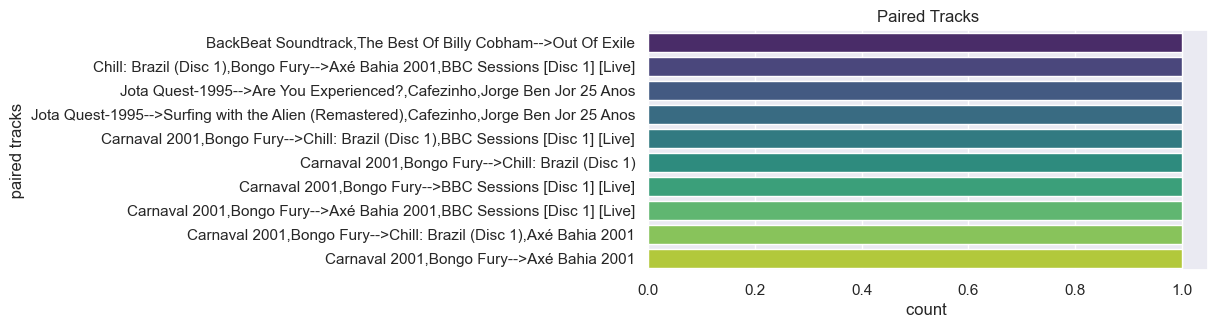

In [87]:
## importing warning to suppress future warnings message
import warnings
with warnings.catch_warnings():
    warnings.simplefilter(action='ignore', category=FutureWarning)

    #select top 10 by antecedents
    top_10 = data_reduce.head(10)

    
    #create a bar plot with seaborn showing count of paired  tracks  
    sns.set(rc ={"figure.figsize":(8,4)})
    ax= sns.barplot(y='pair', x='count', data= top_10, palette='viridis')
    plt.subplots_adjust(left=0.15,right=0.85,top=0.85,bottom=0.25)
  
    plt.xlabel('count ')
    plt.ylabel(' paired tracks ')
    plt.title('Paired Tracks') 
    plt.savefig('seaborn_plot6.png')

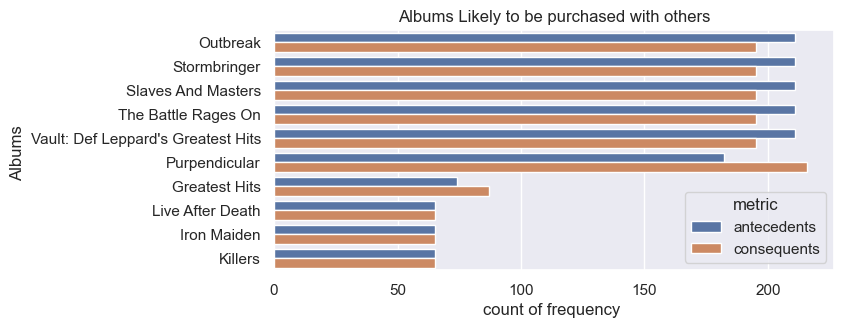

In [88]:
## importing warning to suppress future warnings message
import warnings
with warnings.catch_warnings():
    warnings.simplefilter(action='ignore', category=FutureWarning)

    #select top 15 by antecedents
    top_10 = Data_set.nlargest(10, 'antecedents')

    #melt the dataframeto a long format
    data_melted= pd.melt(top_10, id_vars=['Album Name'], value_vars=['antecedents', 'consequents'],var_name= 'metric', value_name='count of asso')

    #create a bar plot with seaborn showing comparison of albums across antecedents and consequents 
    sns.set(rc ={"figure.figsize":(8,4)})
    ax= sns.barplot(y='Album Name', x='count of asso', hue ='metric', data=data_melted)
    plt.subplots_adjust(left=0.15,right=0.85,top=0.85,bottom=0.25)
  
    plt.xlabel('count of frequency ')
    plt.ylabel('Albums ')
    plt.title('Albums Likely to be purchased with others') 
    plt.savefig('seaborn_plot5.png')